# Permutation Test for PC1 Scores of Metro and Nonmetro Counties

Authors: Savannah Drake and Rory Gardner \
Date: 12/8/2025

In [1]:
# data and libraries

import numpy as np
import pandas as pd

monthly = pd.read_csv("data/monthly.csv")

In [2]:
# Defining the funtion

# separate groups
group_m = monthly.loc[monthly['metro_label'] == 1, 'PC1'].to_numpy(dtype=float)
group_nm = monthly.loc[monthly['metro_label'] == 0, 'PC1'].to_numpy(dtype=float)

np.random.seed(42) # seed

def permutation_test(group_a, group_b, num_permutations=10000): 
    """
    Permutation test for average PC1 scores

    Args: 
        group_a: numpy array-like  object with scores for first group
        group_a: numpy array-like  object with scores for second group
        num_permutations (int): number of permutations

    Returns: 
        p-value 
    """
    group_a = np.array(group_a) # convert to groups
    group_b = np.array(group_b)

    n_a = len(group_a)
    combined = np.concatenate((group_a, group_b))
    observed_diff = np.mean(group_a) - np.mean(group_b)

    count = 0

    for _ in range(num_permutations):
        perm = np.random.permutation(combined)
        perm_diff = np.mean(perm[:n_a]) - np.mean(perm[n_a:])
                
        if np.abs(perm_diff) >= np.abs(observed_diff):
            count += 1
                    
    # Include the observed case in the calculation (+1)
    return (count + 1) / (num_permutations + 1)


p_value = permutation_test(group_m, group_nm)
print(p_value)

9.999000099990002e-05


In [3]:
observed_diff = np.mean(group_m) - np.mean(group_nm)
print(observed_diff)

n_perms = 10000
diffs = np.zeros(n_perms)

all_pc1 = monthly['PC1'].values
metro_i = monthly['metro_label'] == 1
n_metro = sum(metro_i)

for i in range(n_perms): 
    perms = np.random.permutation(all_pc1)

    perm_metro = perms[:n_metro]
    perm_non = perms[n_metro:]

    diffs[i] = np.mean(perm_metro) - np.mean(perm_non)

p_val = np.mean(np.abs(diffs) >= np.abs(observed_diff))
print(p_val)


-1.9307114151201739
0.0


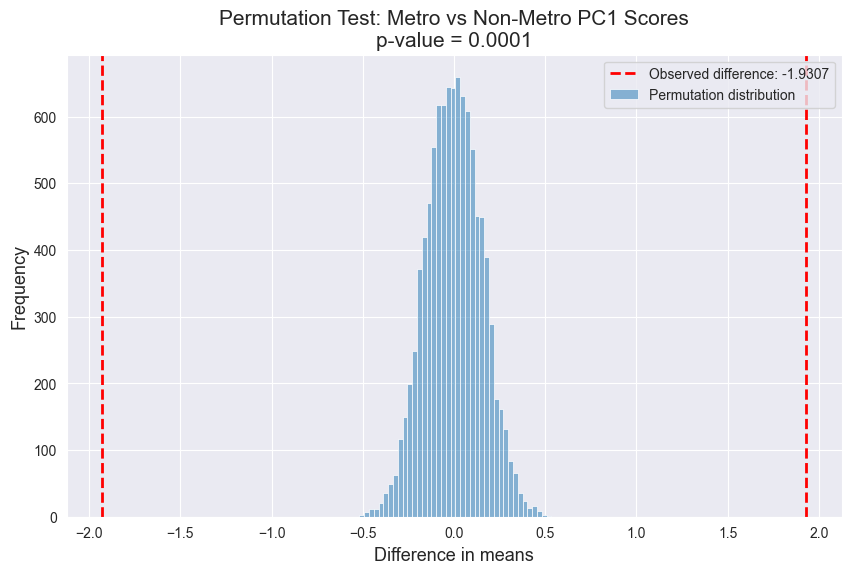

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")
plt.figure(figsize=(10, 6))
sns.histplot(diffs, bins=40, alpha=0.5, label='Permutation distribution', 
             linewidth=0.5)
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2, 
            label=f'Observed difference: {observed_diff:.4f}')

plt.axvline(-observed_diff, color='red', linestyle='dashed', linewidth=2)

plt.title(f'Permutation Test: Metro vs Non-Metro PC1 Scores\np-value = {p_value:.4f}', fontsize=15)
plt.xlabel('Difference in means', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.legend()
plt.show()